In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv("Auto Sales.csv")
df.shape

(2747, 20)

In [5]:
df.head()

,ORDERNUMBER,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,ORDERDATE,DAYS_SINCE_LASTORDER,STATUS,PRODUCTLINE,MSRP,PRODUCTCODE,CUSTOMERNAME,PHONE,ADDRESSLINE1,CITY,POSTALCODE,COUNTRY,CONTACTLASTNAME,CONTACTFIRSTNAME,DEALSIZE
0,10107,30,95.70,2,2871.00,24/02/2018,828,Shipped,Motorcycles,95,S10_1678,Land of Toys Inc.,2125557818,897 Long Airport Avenue,NYC,10022,USA,Yu,Kwai,Small
1,10121,34,81.35,5,2765.90,7/5/2018,757,Shipped,Motorcycles,95,S10_1678,Reims Collectables,26.47.1555,59 rue de l'Abbaye,Reims,51100,France,Henriot,Paul,Small
2,10134,41,94.74,2,3884.34,1/7/2018,703,Shipped,Motorcycles,95,S10_1678,Lyon Souveniers,+33 1 46 62 7555,27 rue du Colonel Pierre Avia,Paris,75508,France,Da Cunha,Daniel,Medium
3,10145,45,83.26,6,3746.70,25/08/2018,649,Shipped,Motorcycles,95,S10_1678,Toys4GrownUps.com,6265557265,78934 Hillside Dr.,Pasadena,90003,USA,Young,Julie,Medium
4,10168,36,96.66,1,3479.76,28/10/2018,586,Shipped,Motorcycles,95,S10_1678,Technics Stores Inc.,6505556809,9408 Furth Circle,Burlingame,94217,USA,Hirano,Juri,Medium


In [6]:
df.isnull().sum()

ORDERNUMBER             0
QUANTITYORDERED         0
PRICEEACH               0
ORDERLINENUMBER         0
SALES                   0
ORDERDATE               0
DAYS_SINCE_LASTORDER    0
STATUS                  0
PRODUCTLINE             0
MSRP                    0
PRODUCTCODE             0
CUSTOMERNAME            0
PHONE                   0
ADDRESSLINE1            0
CITY                    0
POSTALCODE              0
COUNTRY                 0
CONTACTLASTNAME         0
CONTACTFIRSTNAME        0
DEALSIZE                0
dtype: int64

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2747 entries, 0 to 2746
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   ORDERNUMBER           2747 non-null   int64  
 1   QUANTITYORDERED       2747 non-null   int64  
 2   PRICEEACH             2747 non-null   float64
 3   ORDERLINENUMBER       2747 non-null   int64  
 4   SALES                 2747 non-null   float64
 5   ORDERDATE             2747 non-null   object 
 6   DAYS_SINCE_LASTORDER  2747 non-null   int64  
 7   STATUS                2747 non-null   object 
 8   PRODUCTLINE           2747 non-null   object 
 9   MSRP                  2747 non-null   int64  
 10  PRODUCTCODE           2747 non-null   object 
 11  CUSTOMERNAME          2747 non-null   object 
 12  PHONE                 2747 non-null   object 
 13  ADDRESSLINE1          2747 non-null   object 
 14  CITY                  2747 non-null   object 
 15  POSTALCODE           

# EDA
# Count of Product Line

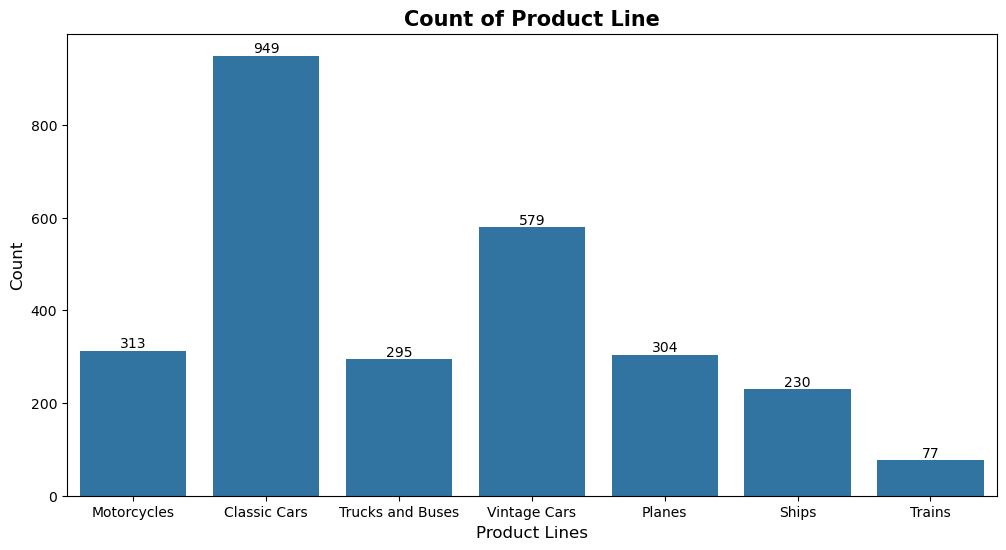

In [44]:
fig, ax = plt.subplots(figsize = (12,6))
ax = sns.countplot(x = 'PRODUCTLINE', data = df)
ax.set_title('Count of Product Line', fontsize = 15, fontweight = 'bold')
ax.set_ylabel('Count', fontsize = 12)
ax.set_xlabel('Product Lines', fontsize = 12)
ax.bar_label(ax.containers[0])
plt.show()


The chart shows that Classic Cars are by far the most popular product line, while Trains are the least common. Most categories have between 200 and 600 items, but Classic Cars stand out as the clear leader in the collection.

# Count of Order Status

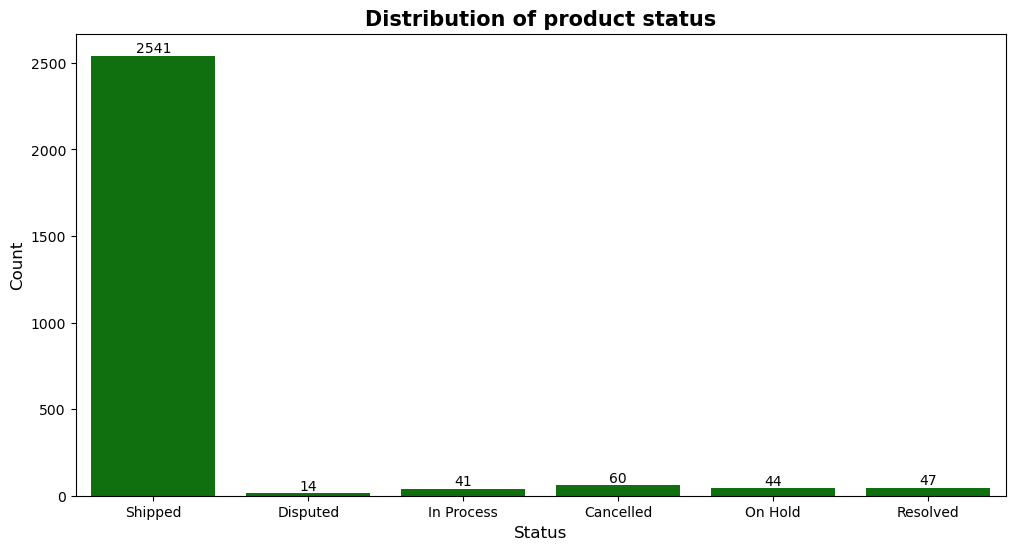

In [14]:
fig, ax = plt.subplots(figsize = (12,6))
ax = sns.countplot(x = 'STATUS', data = df, color = 'green')
ax.set_title('Distribution of product status', fontsize = 15, fontweight = 'bold')
ax.set_ylabel('Count', fontsize = 12)
ax.set_xlabel('Status', fontsize = 12)
ax.bar_label(ax.containers[0])
plt.show()


The vast majority of orders have been Shipped, representing the bulk of the operations. All other statuses, such as Disputed, In Process, or Cancelled, make up only a tiny fraction of the total count, indicating a very high completion rate.

# Analysis - Cancelled Orders by Product Lines

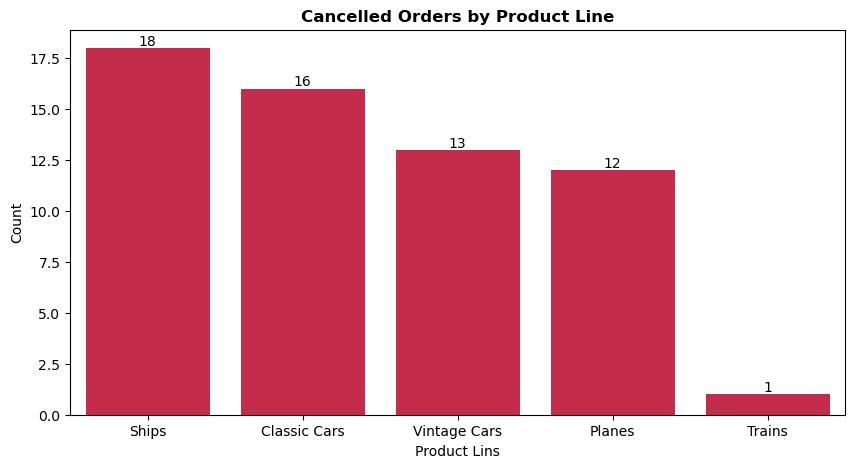

In [43]:
cancelled_counts = df[df['STATUS'] == 'Cancelled'] \
    .groupby('PRODUCTLINE') \
    .size() \
    .sort_values(ascending=False)

ax = plt.subplots(figsize=(10, 5))
ax = sns.barplot(x=cancelled_counts.index, y=cancelled_counts.values, color='crimson')
ax.set_title('Cancelled Orders by Product Line', fontweight='bold')
ax.set_xlabel('Product Lins')
ax.set_ylabel('Count')
ax.bar_label(ax.containers[0])
plt.show()

Ships and Classic Cars have the highest number of cancellations, while Trains have almost none. Most product lines see a similar level of cancelled orders, typically ranging between 12 and 18.

# Analysis - Disputed Orders by Product Line

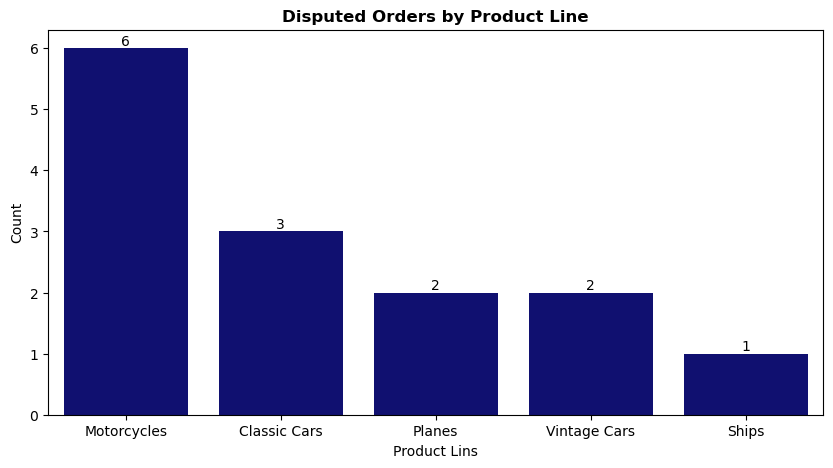

In [47]:
disputed_counts = df[df['STATUS'] == 'Disputed'] \
    .groupby('PRODUCTLINE') \
    .size() \
    .sort_values(ascending=False)

ax = plt.subplots(figsize=(10, 5))
ax = sns.barplot(x=disputed_counts.index, y=disputed_counts.values, color='navy')
ax.set_title('Disputed Orders by Product Line', fontweight='bold')
ax.set_xlabel('Product Lins')
ax.set_ylabel('Count')
ax.bar_label(ax.containers[0])
plt.show()
                     

Motorcycles have the highest number of disputes, followed by Classic Cars. Overall, dispute counts are very low across all categories, with none exceeding six total instances.

# Analysis - Disputed Orders by Countries

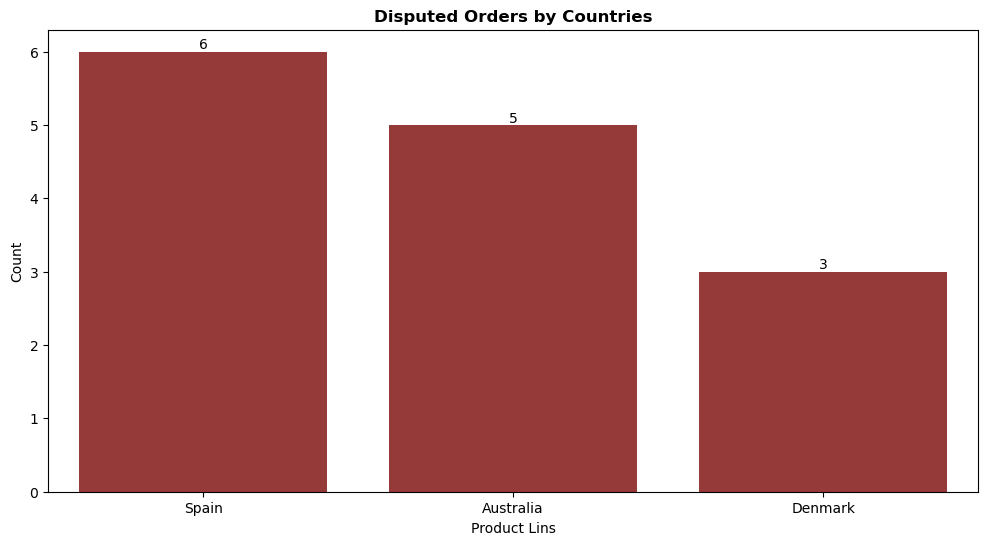

In [51]:
disputed_counts = df[df['STATUS'] == 'Disputed'] \
    .groupby('COUNTRY') \
    .size() \
    .sort_values(ascending=False)

ax = plt.subplots(figsize=(12, 6))
ax = sns.barplot(x=disputed_counts.index, y=disputed_counts.values, color='brown')
ax.set_title('Disputed Orders by Countries', fontweight='bold')
ax.set_xlabel('Product Lins')
ax.set_ylabel('Count')
ax.bar_label(ax.containers[0])
plt.show()
                     

Spain has the highest number of disputed orders, followed closely by Australia. Denmark has the fewest disputes among the three countries listed, with only half the amount seen in Spain.

# Analysis - Cancelled Orders by Countries

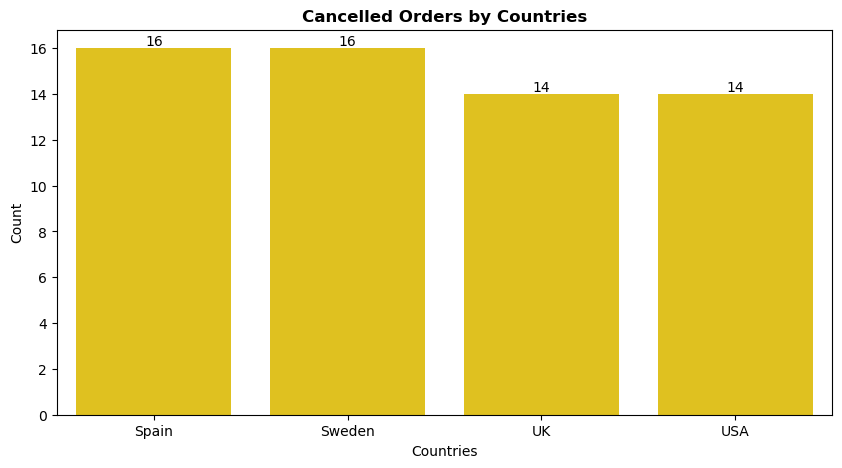

In [63]:
cancelled_counts = df[df['STATUS'] == 'Cancelled'] \
    .groupby('COUNTRY') \
    .size() \
    .sort_values(ascending=False)

ax = plt.subplots(figsize=(10, 5))
ax = sns.barplot(x=cancelled_counts.index, y=cancelled_counts.values, color='gold')
ax.set_title('Cancelled Orders by Countries', fontweight='bold')
ax.set_xlabel('Countries')
ax.set_ylabel('Count')
ax.bar_label(ax.containers[0])
plt.show()

Cancelled orders are distributed almost evenly across these four countries, with Spain and Sweden tied for the highest count. The UK and USA follow closely behind, with only two fewer cancellations each.

# Analysis - Sales by Product Lines

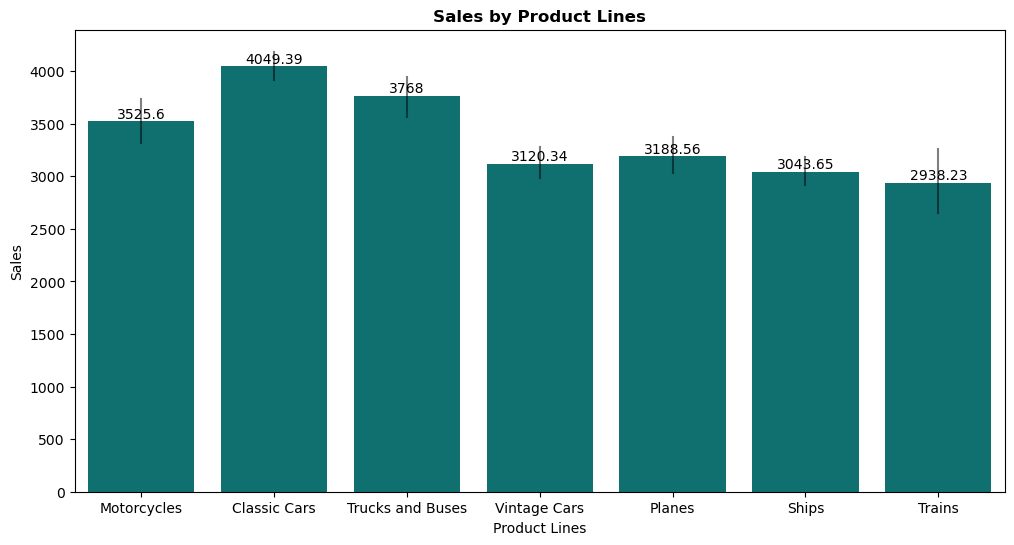

In [58]:
df.groupby("PRODUCTLINE")["SALES"].mean()
ax = plt.subplots(figsize=(12, 6))
ax = sns.barplot(x='PRODUCTLINE', y='SALES', color='teal', data =df, err_kws={'color': 'black', 'alpha': 0.5, 'linewidth': 1.5})
ax.set_title('Sales by Product Lines', fontweight='bold')
ax.set_xlabel('Product Lines')
ax.set_ylabel('Sales')
ax.bar_label(ax.containers[0])
plt.show()

Classic Cars generate the highest sales revenue, followed by Trucks and Buses. While Trains contribute the least to overall sales, most product lines maintain a relatively steady performance, with individual averages staying between 3,000 and 4,000.

# Analysis - Sales by Country

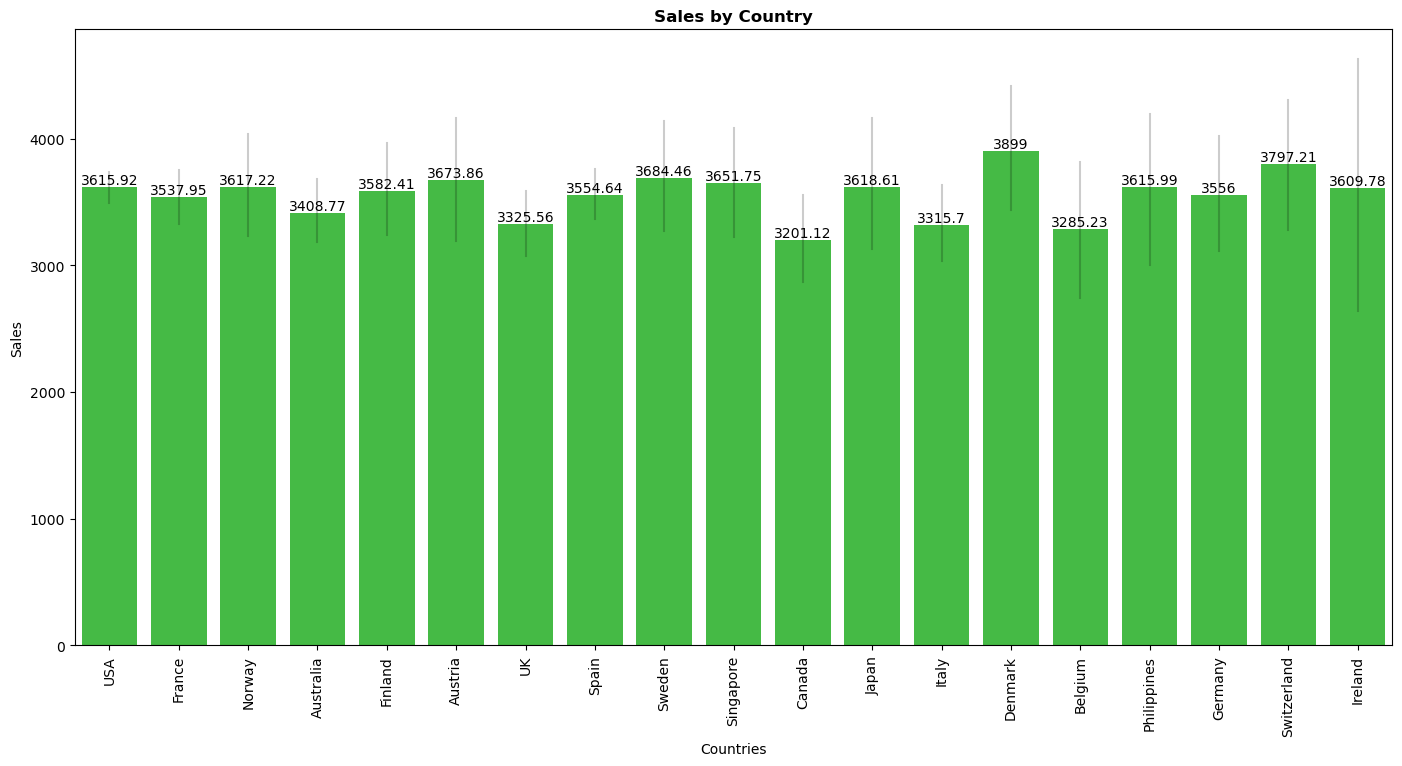

In [62]:
df.groupby("COUNTRY")["SALES"].mean()
ax = plt.subplots(figsize=(17, 8))
ax = sns.barplot(x='COUNTRY', y='SALES', color='limegreen', data =df, err_kws={'color': 'black', 'alpha': 0.2, 'linewidth': 1.5})
ax.set_title('Sales by Country', fontweight='bold')
ax.set_xlabel('Countries')
ax.set_ylabel('Sales')
ax.bar_label(ax.containers[0])
plt.xticks(rotation=90)
plt.show()

Average sales are consistent across countries (3,300–3,700), led by Denmark and Switzerland. The error bars show that countries like Ireland have high variability (mixed small and large orders), while overlapping bars across the chart prove that most nations are performing at nearly the same level.

# Analysis - Sales by deal size

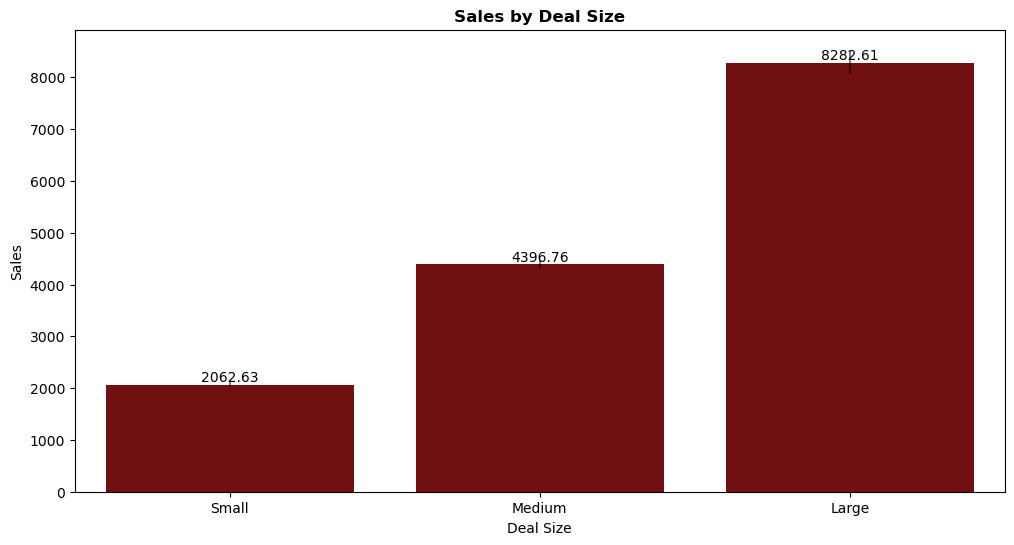

In [55]:
df.groupby("DEALSIZE")["SALES"].mean()
ax = plt.subplots(figsize=(12, 6))
ax = sns.barplot(x='DEALSIZE', y='SALES', color='maroon', data =df, err_kws={'color': 'black', 'alpha': 0.5, 'linewidth': 1.5})
ax.set_title('Sales by Deal Size', fontweight='bold')
ax.set_xlabel('Deal Size')
ax.set_ylabel('Sales')
ax.bar_label(ax.containers[0])
plt.show()

Large deals generate significantly higher average revenue than Medium or Small ones. The very short error bars across all three categories indicate that sales within each group are highly consistent and predictable with very little variation.

# OBSERVATIONS

1. Focus expansion on Denmark and Switzerland due to stable and consistent revenue with low variability

2. Large deal customers generate maximum revenue and show highly predictable spending behavior

3. Promote Classic Cars and Trucks & Buses as they drive the highest sales and demand

4. Fix issues in Ships (high cancellations) and Motorcycles (high disputes), and reconsider strategy for Trains due to low demand.

5. Target high-value, repeat large-deal customers with low disputes/cancellations as potential loyal customers for retention strategies